In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

df = pd.read_csv(r"C:\Users\jason\OneDrive\Documents\Python Projects\Loan_approval_data_2025.csv")

print("Shape:", df.shape)
display(df.head())
print(df.info())


Shape: (50000, 20)


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [5]:
# ================================
# 2. BASIC DATA QUALITY CHECKS
# ================================

# Count how many duplicate rows exist in the dataset.
# Duplicate rows might indicate data entry errors or repeated records.
print("Duplicate rows:", df.duplicated().sum())

# Check for missing values in each column.
# This tells you which features might need imputation or special handling.
print("\nMissing values per column:")
print(df.isna().sum())

# Generate summary statistics for all numeric columns.
# Includes count, mean, std deviation, min, max, and quartiles.
# This helps you understand the scale, distribution, and potential outliers.
print("\nSummary statistics for numeric columns:")
display(df.describe().T)  # .T transposes so each row is a feature, easier to read


Duplicate rows: 0

Missing values per column:
customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
age,50000.0,34.957060,11.118603,18.000,26.000,35.000,43.00000,70.000
years_employed,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
annual_income,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
credit_score,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
credit_history_years,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
savings_assets,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
current_debt,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
defaults_on_file,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
delinquencies_last_2yrs,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
derogatory_marks,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


In [6]:
# ================================
# 3. SEPARATE NUMERIC & CATEGORICAL FEATURES
# ================================

# Select all columns with numeric data types (int, float).
# These will be used for statistical analysis, correlations, etc.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Select all columns with object or category types (strings, categories).
# These are usually things like occupation, loan intent, etc.
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

# Set the name of the target column for classification.
# In this dataset, 'loan_status' is 1 for approved and 0 for denied.
target_col = "loan_status"

# Remove the target from the list of numeric predictors so we don't treat it as a feature.
if target_col in numeric_cols:
    numeric_cols.remove(target_col)


Numeric columns: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status']
Categorical columns: ['customer_id', 'occupation_status', 'product_type', 'loan_intent']


Loan status counts:
loan_status
1    27523
0    22477
Name: count, dtype: int64

Loan status proportions:
loan_status
1    0.55046
0    0.44954
Name: proportion, dtype: float64


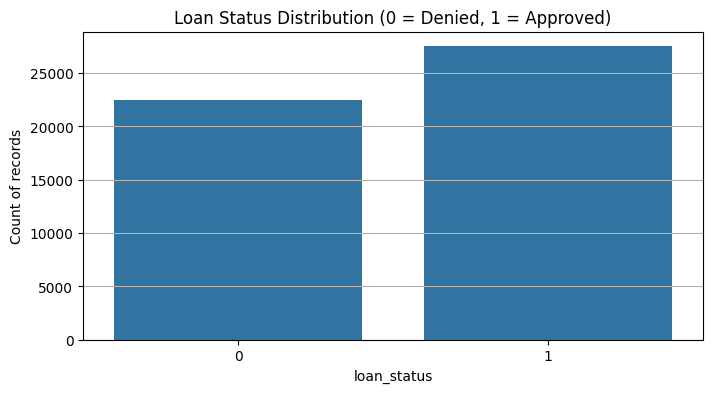

In [7]:
# ================================
# 4. TARGET VARIABLE OVERVIEW
# ================================

# Count how many approved (1) and denied (0) loans there are.
# This helps you see if the classes are balanced or imbalanced.
print("Loan status counts:")
print(df[target_col].value_counts())

# Show the same counts but as proportions (0 to 1).
# For example, 0.7 for approved means 70% approval rate in the dataset.
print("\nLoan status proportions:")
print(df[target_col].value_counts(normalize=True))

# Visualize the class balance using a simple bar chart.
# If one bar is much taller than the other, you have class imbalance,
# which is important for modeling later.
sns.countplot(x=target_col, data=df)
plt.title("Loan Status Distribution (0 = Denied, 1 = Approved)")
plt.xlabel("loan_status")
plt.ylabel("Count of records")
plt.show()


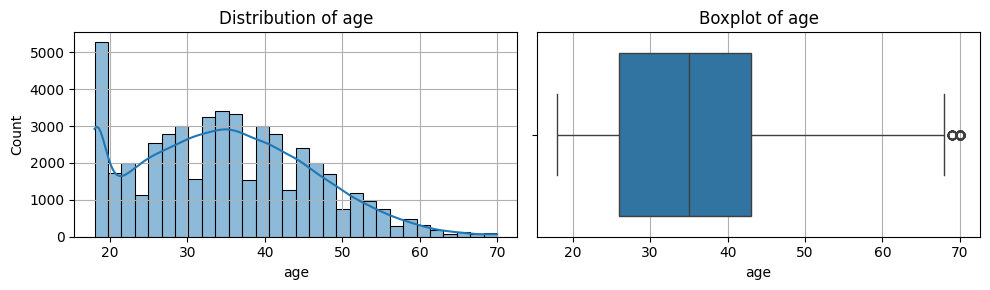

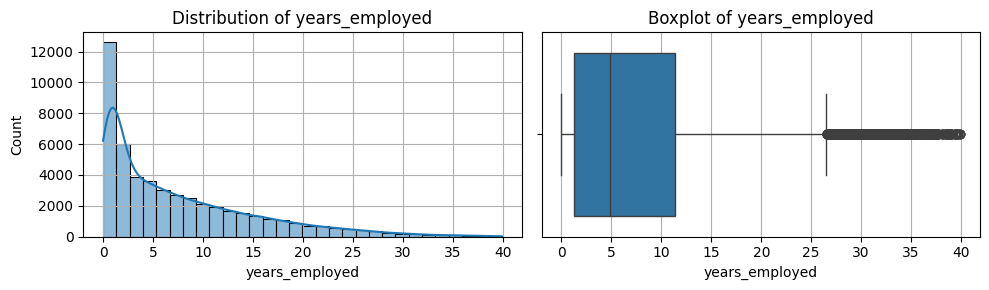

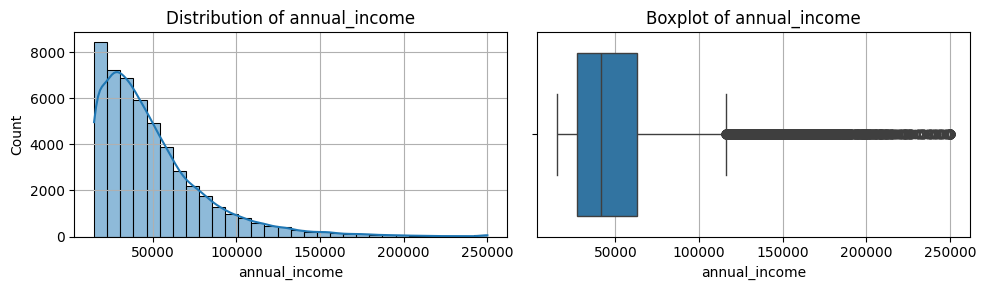

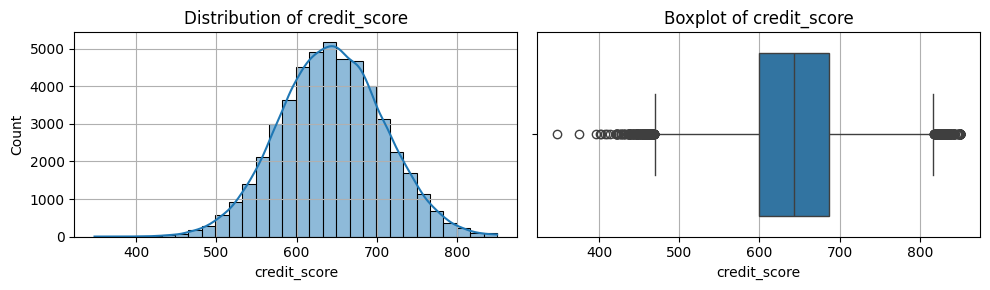

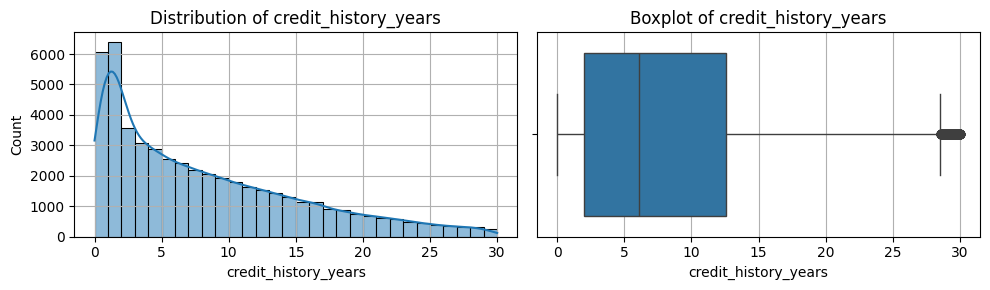

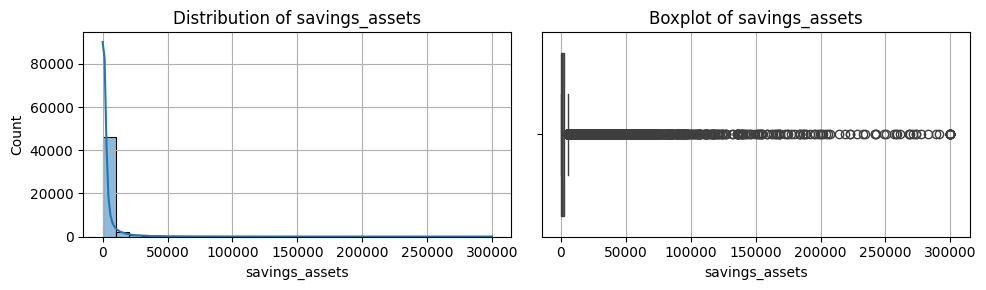

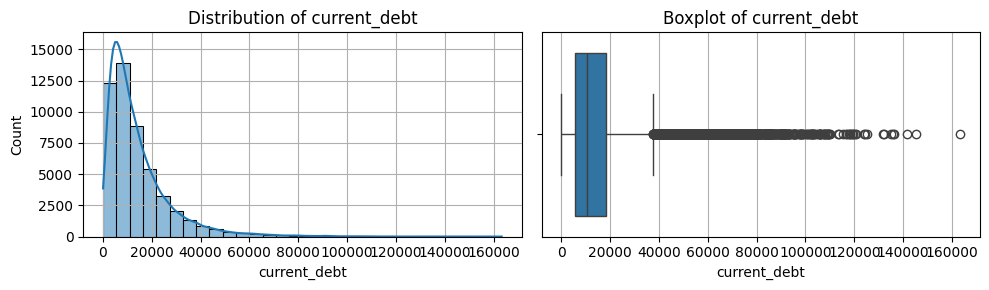

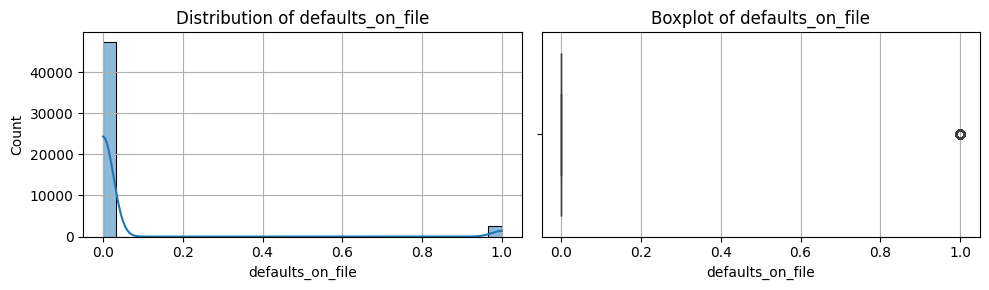

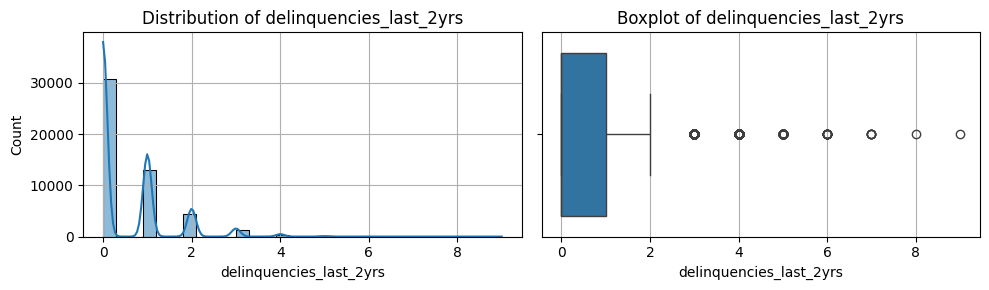

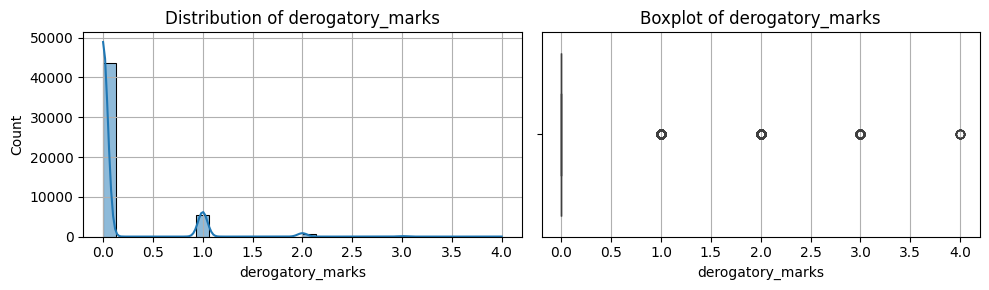

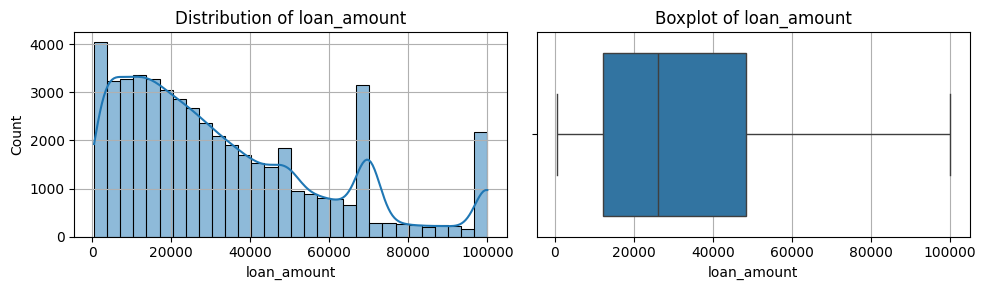

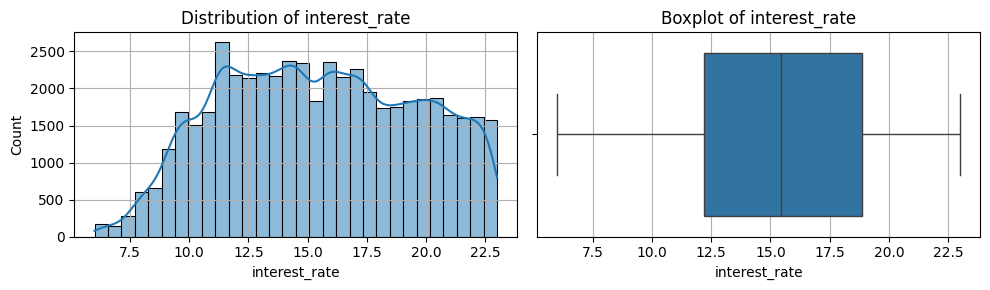

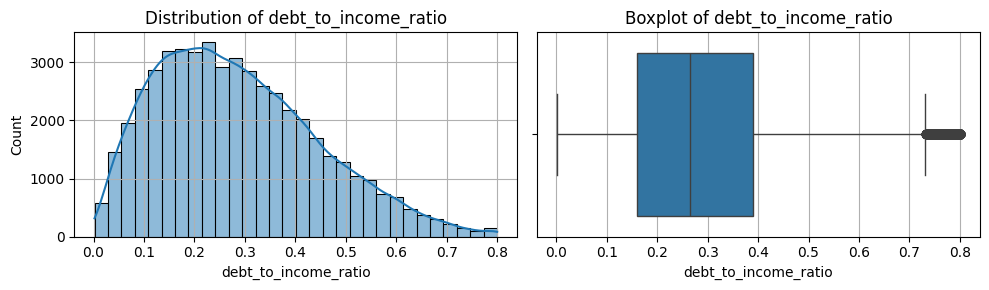

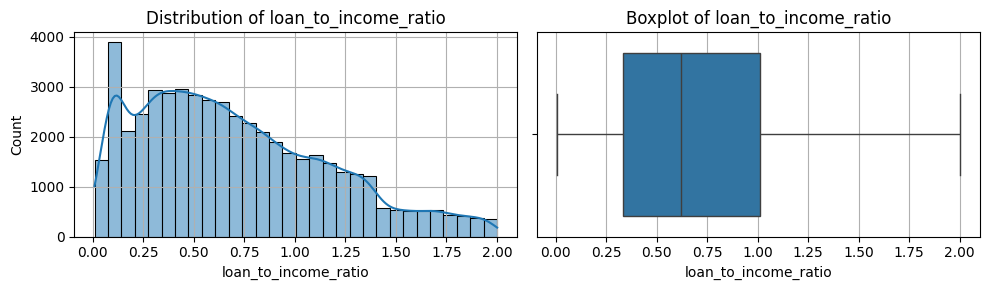

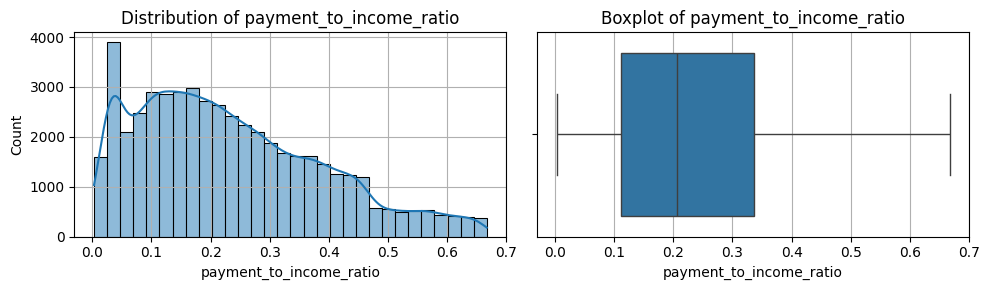

In [8]:
# ================================
# 5. UNIVARIATE ANALYSIS – NUMERIC FEATURES
# ================================

# For each numeric column, plot:
# - A histogram: shows the distribution (e.g., normal, skewed, long tail)
# - A boxplot: shows median, IQR, and potential outliers
for col in numeric_cols:
    # Create a row with two plots side by side
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))

    # Left: Histogram with optional KDE (smooth curve of distribution)
    sns.histplot(df[col], bins=30, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    ax[0].set_xlabel(col)

    # Right: Boxplot to show spread and outliers
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")
    ax[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()



Value counts for customer_id:
customer_id
CUST100000    1
CUST100001    1
CUST100002    1
CUST100003    1
CUST100004    1
CUST100005    1
CUST100006    1
CUST100007    1
CUST100008    1
CUST100009    1
Name: count, dtype: int64


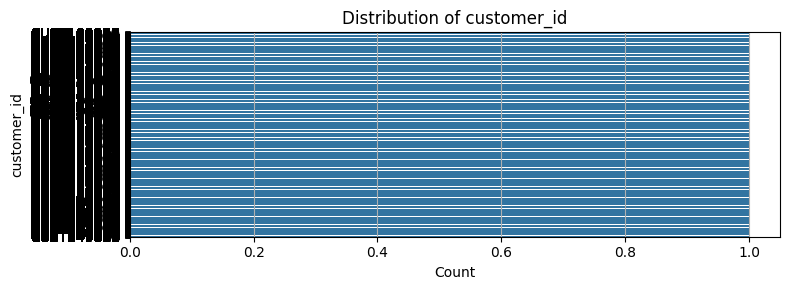


Value counts for occupation_status:
occupation_status
Employed         34971
Self-Employed    10179
Student           4850
Name: count, dtype: int64


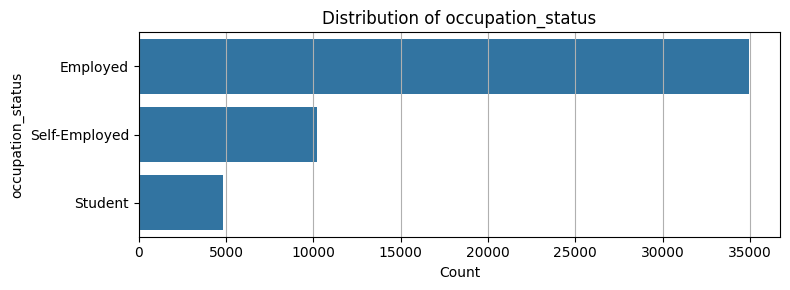


Value counts for product_type:
product_type
Credit Card       22455
Personal Loan     17523
Line of Credit    10022
Name: count, dtype: int64


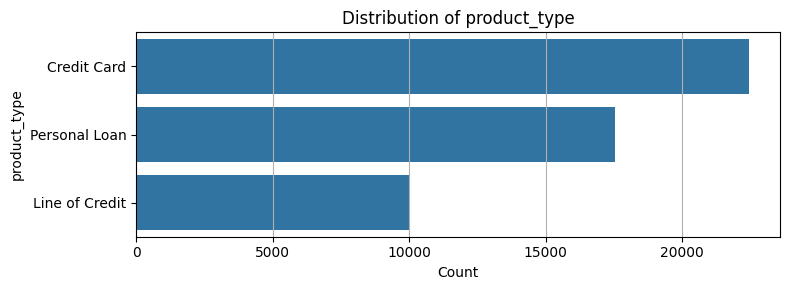


Value counts for loan_intent:
loan_intent
Personal              12429
Education             10134
Medical                7598
Business               7469
Home Improvement       7453
Debt Consolidation     4917
Name: count, dtype: int64


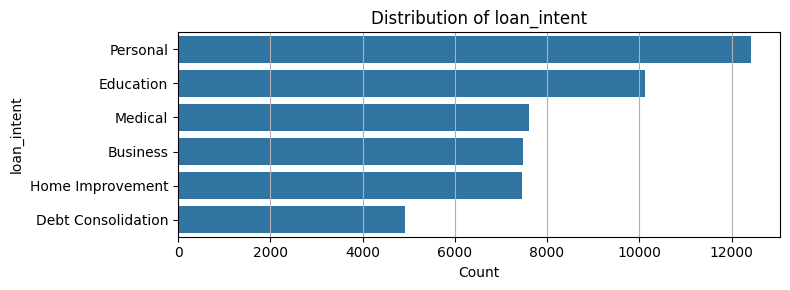

In [9]:
# ================================
# 6. UNIVARIATE ANALYSIS – CATEGORICAL FEATURES
# ================================

# For each categorical column, show:
# - Value counts (top categories)
# - Bar chart of category frequencies
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    # Show the 10 most common categories for this feature
    print(df[col].value_counts().head(10))

    # Plot a horizontal bar chart of category frequencies
    plt.figure(figsize=(8, 3))
    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index  # order bars by frequency
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


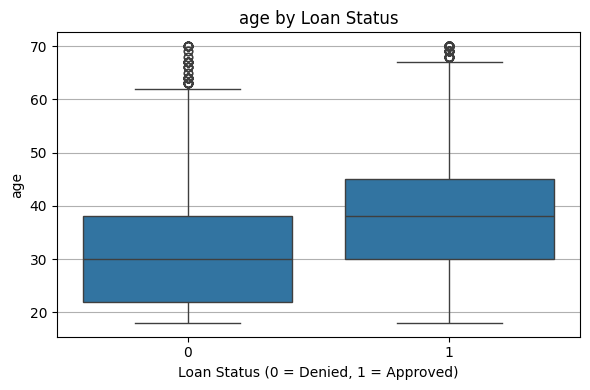

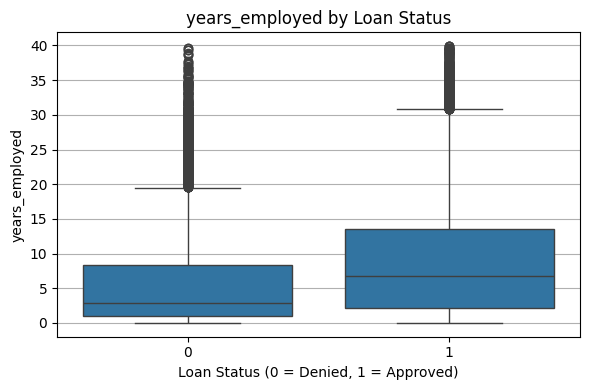

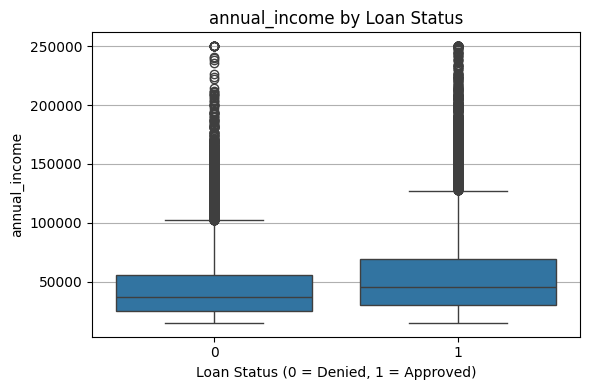

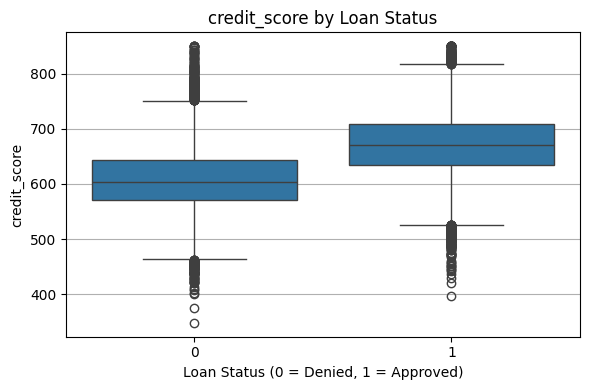

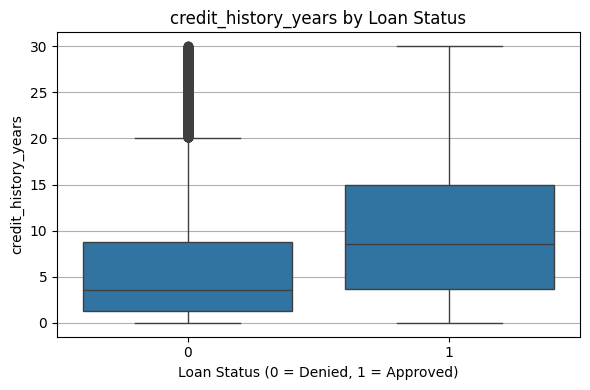

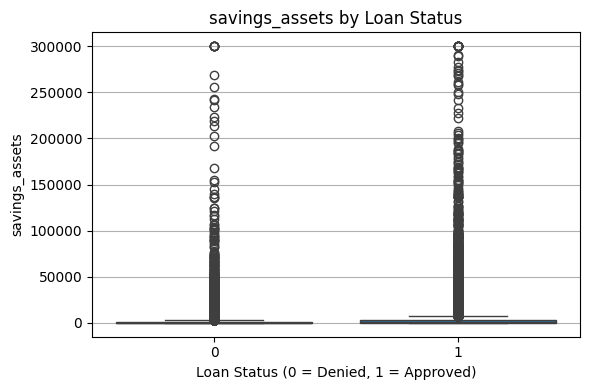

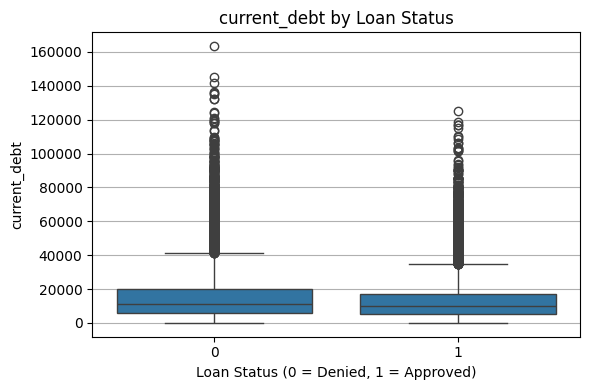

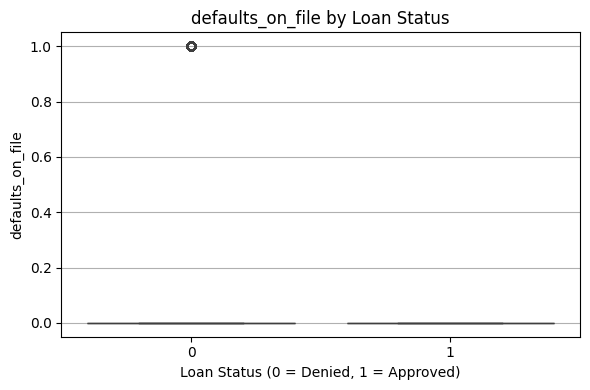

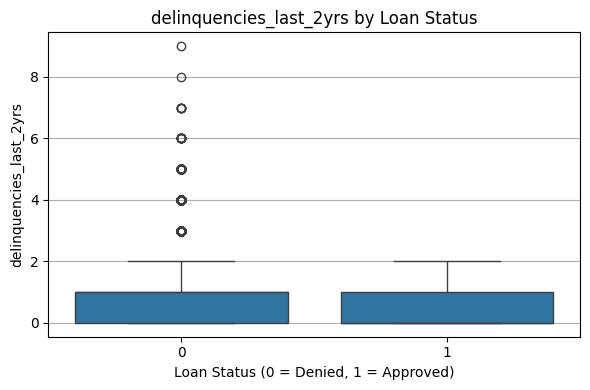

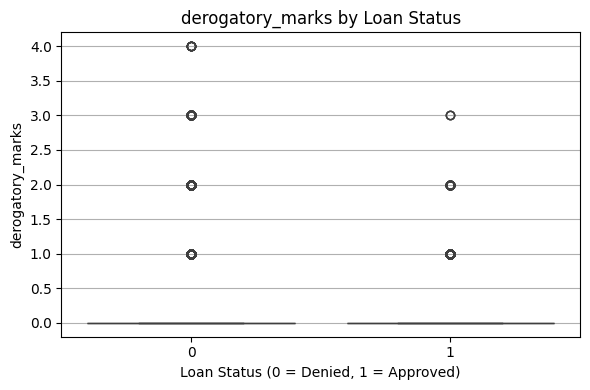

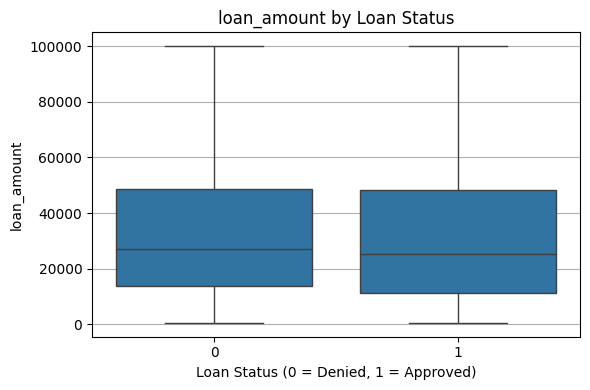

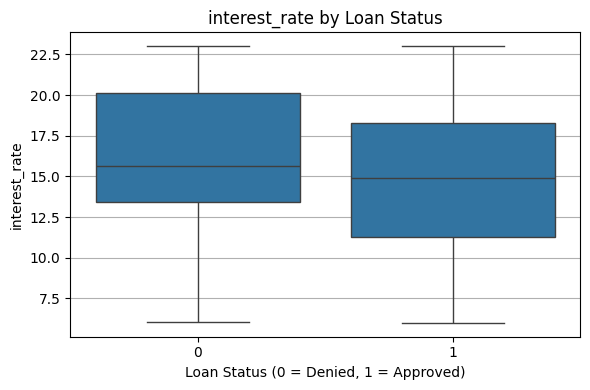

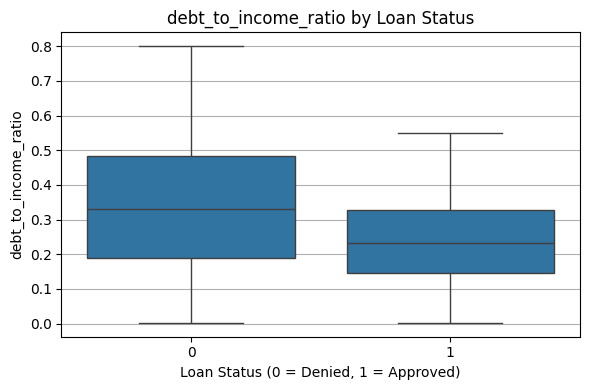

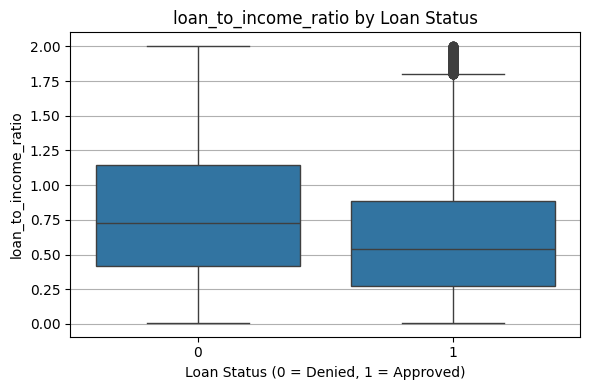

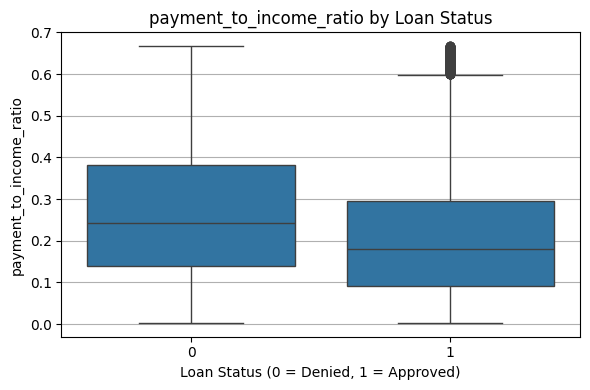

In [10]:
# ================================
# 7. BIVARIATE ANALYSIS – NUMERIC vs TARGET
# ================================

# For each numeric feature, plot a boxplot grouped by loan_status.
# This helps you see how the distribution of each feature differs
# between approved and denied loans.
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by Loan Status")
    plt.xlabel("Loan Status (0 = Denied, 1 = Approved)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



Approval rate by customer_id:
customer_id
CUST149983    1.0
CUST149982    1.0
CUST149978    1.0
CUST149977    1.0
CUST149973    1.0
             ... 
CUST127514    0.0
CUST127512    0.0
CUST127504    0.0
CUST149998    0.0
CUST149997    0.0
Name: loan_status, Length: 50000, dtype: float64


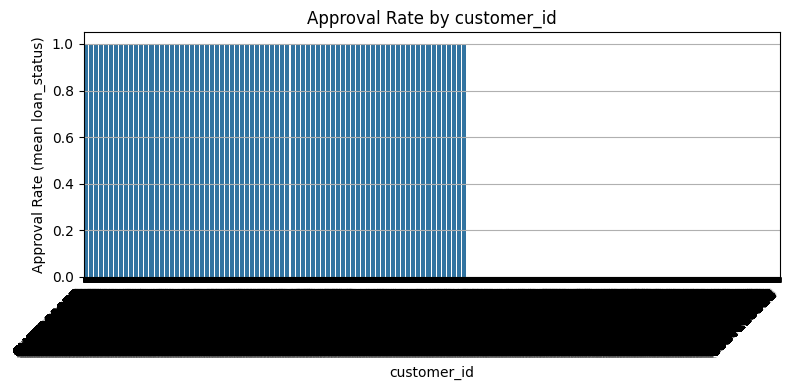


Approval rate by occupation_status:
occupation_status
Self-Employed    0.569113
Student          0.561031
Employed         0.543565
Name: loan_status, dtype: float64


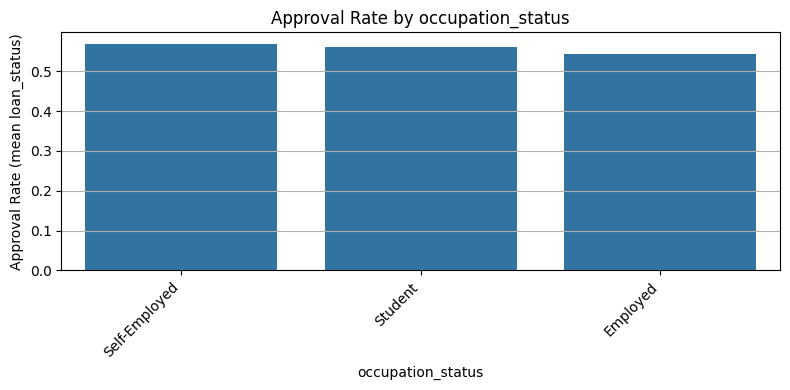


Approval rate by product_type:
product_type
Credit Card       0.613226
Line of Credit    0.532429
Personal Loan     0.480340
Name: loan_status, dtype: float64


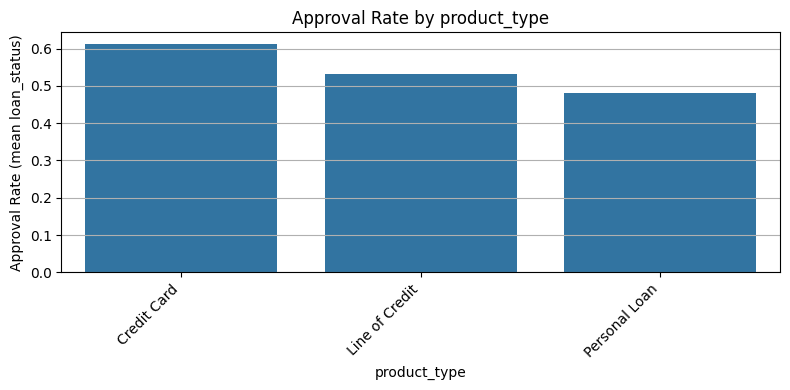


Approval rate by loan_intent:
loan_intent
Education             0.675054
Personal              0.608255
Home Improvement      0.535221
Medical               0.528955
Business              0.443433
Debt Consolidation    0.366484
Name: loan_status, dtype: float64


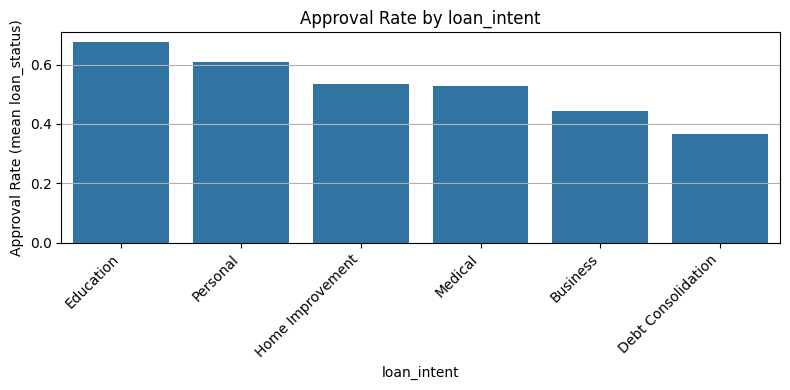

In [11]:
# ================================
# 8. BIVARIATE ANALYSIS – CATEGORICAL vs TARGET
# ================================

# For each categorical feature:
# - Calculate the average loan_status per category
#   (this is the approval rate for that category)
# - Plot those approval rates as a bar chart
for col in cat_cols:
    # Group by category and take the mean of loan_status (1 = approved, 0 = denied).
    # This mean is the approval rate for that category.
    grouped = df.groupby(col)[target_col].mean().sort_values(ascending=False)

    print(f"\nApproval rate by {col}:")
    print(grouped)

    # Plot approval rate for each category in this feature
    plt.figure(figsize=(8, 4))
    sns.barplot(x=grouped.index, y=grouped.values)
    plt.title(f"Approval Rate by {col}")
    plt.xticks(rotation=45, ha="right")  # rotate names so they don't overlap
    plt.ylabel("Approval Rate (mean loan_status)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()



Correlations with loan_status:
loan_status                1.000000
credit_score               0.496316
age                        0.311524
credit_history_years       0.277103
years_employed             0.218875
annual_income              0.158466
savings_assets             0.094789
loan_amount               -0.025987
current_debt              -0.088494
interest_rate             -0.185179
loan_to_income_ratio      -0.193252
payment_to_income_ratio   -0.193258
derogatory_marks          -0.224735
defaults_on_file          -0.263033
debt_to_income_ratio      -0.317363
delinquencies_last_2yrs   -0.318075
Name: loan_status, dtype: float64


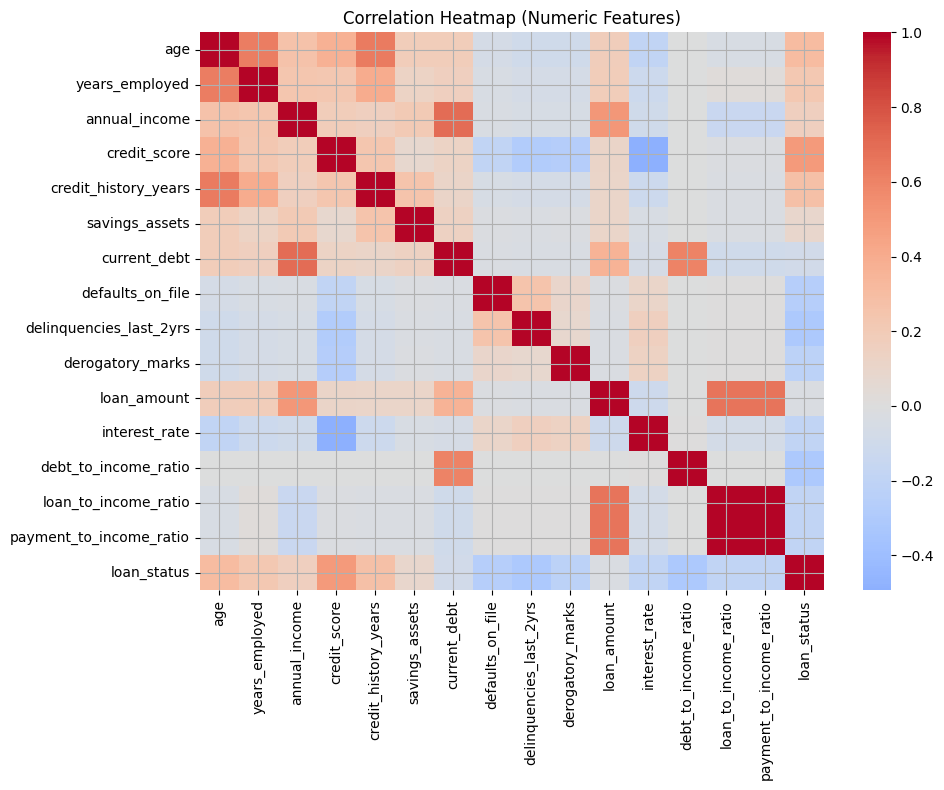

In [12]:
# ================================
# 9. CORRELATION ANALYSIS – NUMERIC FEATURES
# ================================

# Compute the correlation matrix between numeric features and loan_status.
# Correlation ranges from -1 to 1:
# - Positive: they tend to move in the same direction
# - Negative: they move in opposite directions
# - Near 0: little to no linear relationship
corr = df[numeric_cols + [target_col]].corr()

# Show correlations between each numeric feature and the target (loan_status),
# sorted from strongest positive to strongest negative.
print("\nCorrelations with loan_status:")
print(corr[target_col].sort_values(ascending=False))

# Visualize the full correlation matrix as a heatmap.
# Dark red = strong positive, dark blue = strong negative.
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,      # center at 0 so positive and negative are symmetric
    annot=False    # set to True if you want numbers on each cell (can get cluttered)
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


Pairplot on columns: ['loan_status', 'age', 'annual_income', 'credit_score', 'current_debt', 'loan_amount', 'debt_to_income_ratio', 'interest_rate']


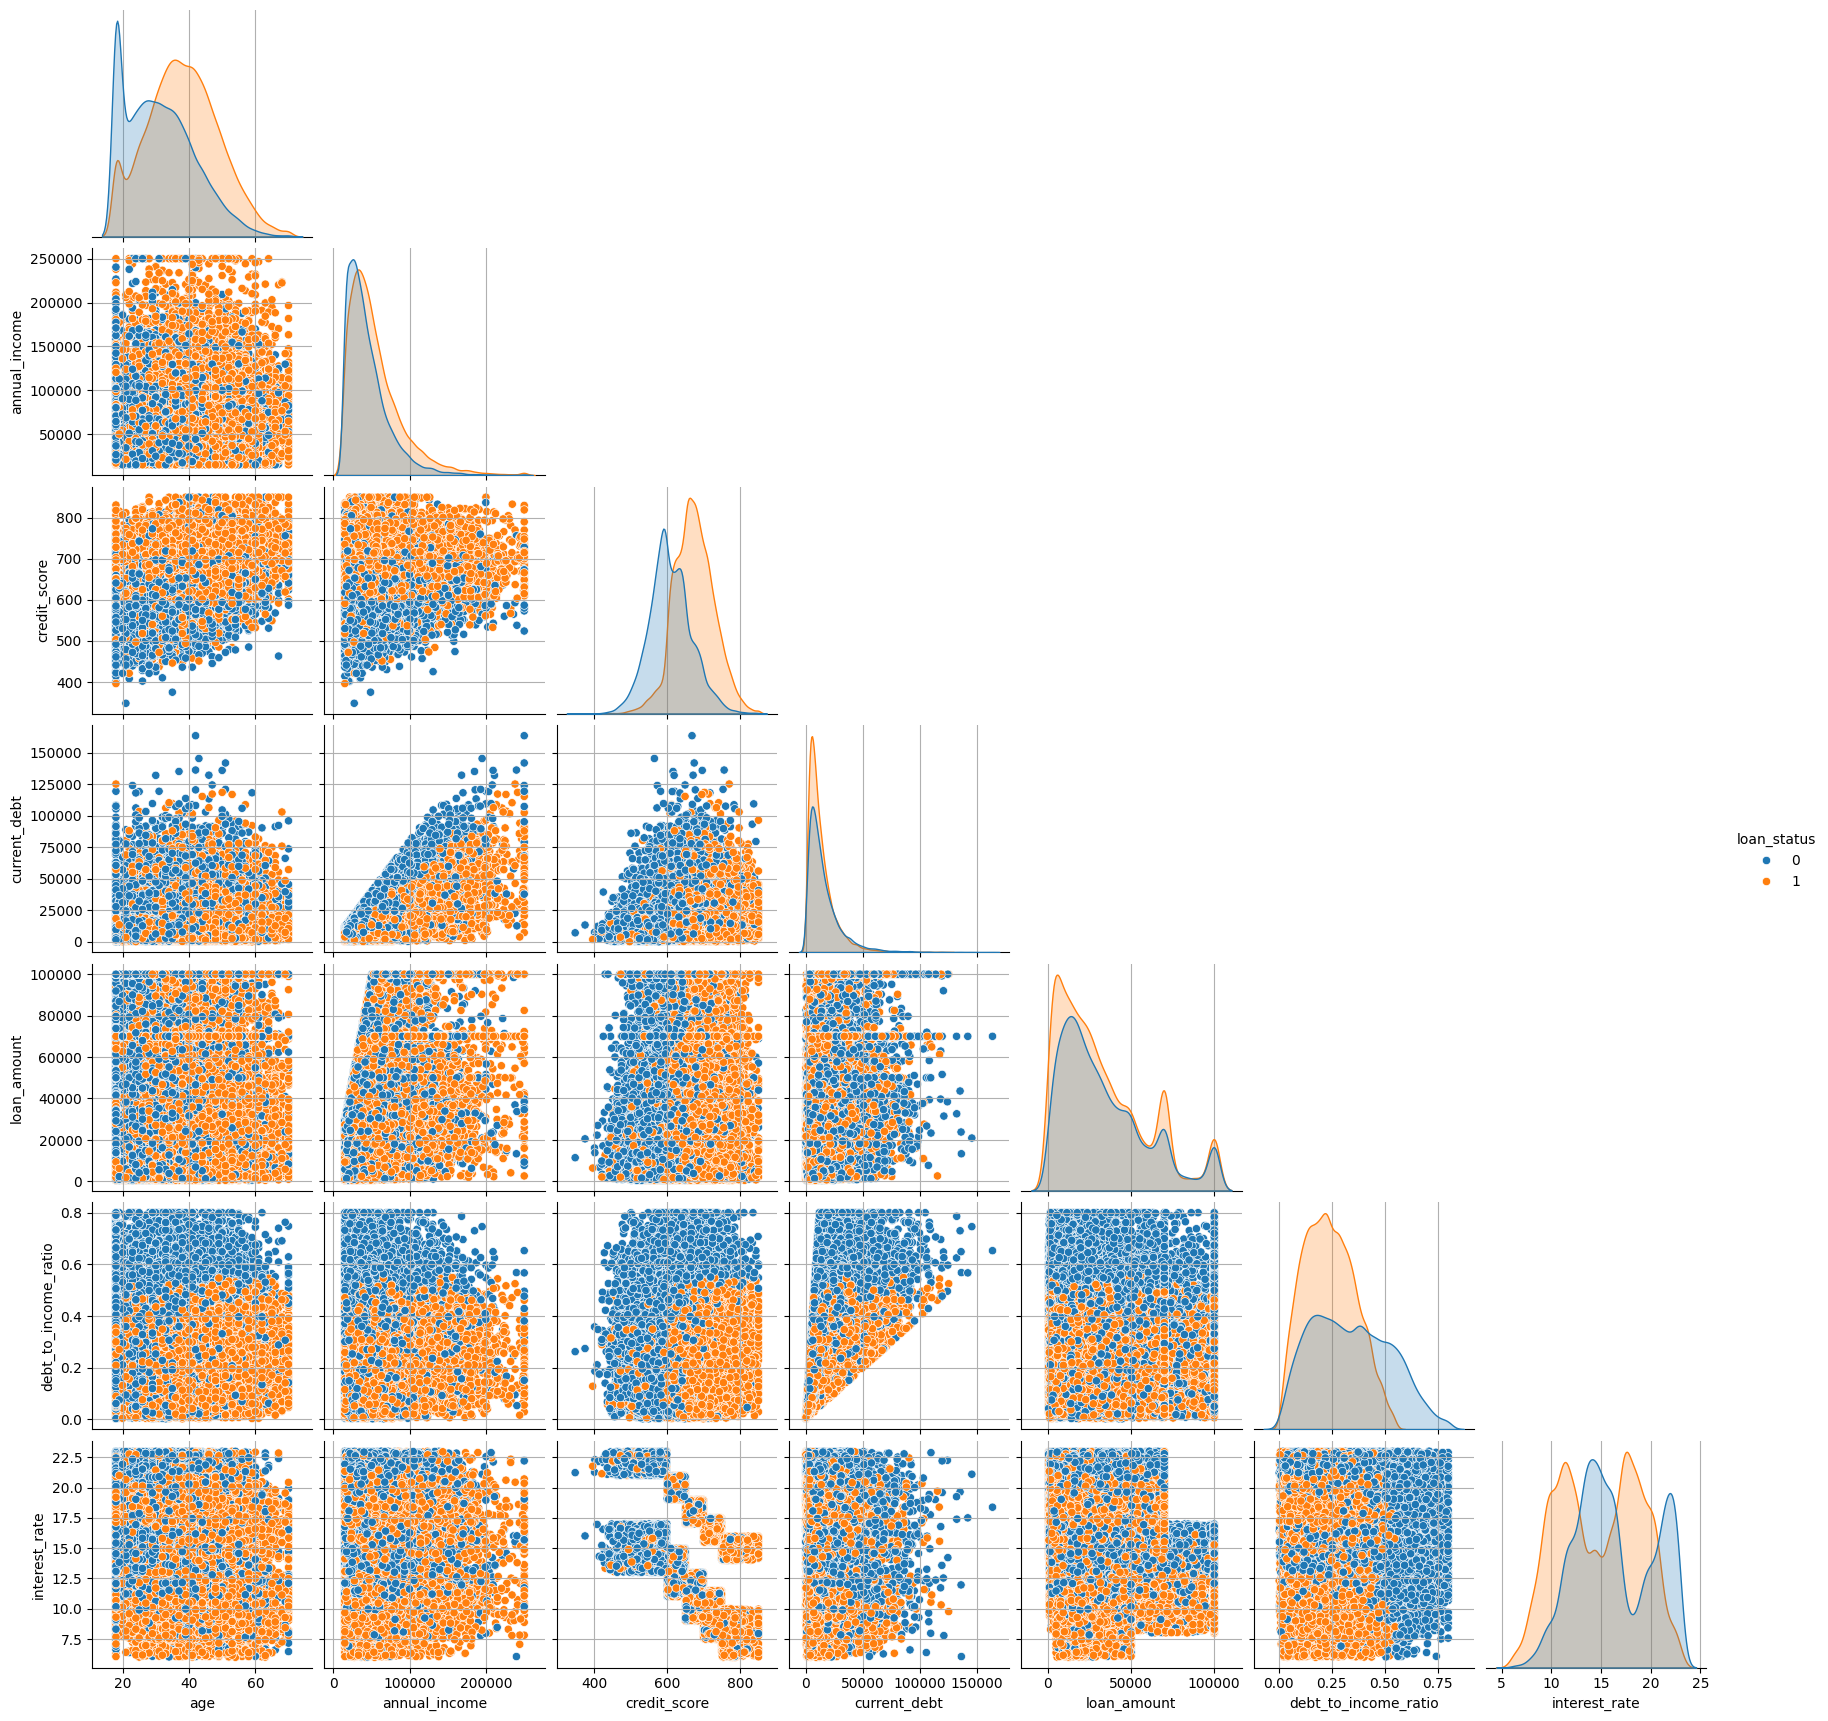

In [13]:
# ================================
# 10. PAIRPLOT – RELATIONSHIPS BETWEEN KEY FEATURES
# ================================

# Build a list of columns to include in the pairplot.
# Start with the target column so we can color points by approval status.
subset = ["loan_status"]

# Add a selection of important numeric features if they exist in the dataset.
# These are typical drivers of loan decisions.
for col in [
    "age",
    "annual_income",
    "credit_score",
    "current_debt",
    "loan_amount",
    "debt_to_income_ratio",
    "interest_rate"
]:
    if col in df.columns:
        subset.append(col)

print("Pairplot on columns:", subset)

# Create a pairplot:
# - Each diagonal: histograms of individual features
# - Off-diagonal: scatter plots between pairs of features
# - Colored by loan_status to see how approved/denied loans differ
sns.pairplot(df[subset], hue="loan_status", corner=True)
plt.show()


## Machine Learning

In [14]:
df          # your DataFrame
target_col = "loan_status"
numeric_cols, cat_cols  # from earlier chunks


(['age',
  'years_employed',
  'annual_income',
  'credit_score',
  'credit_history_years',
  'savings_assets',
  'current_debt',
  'defaults_on_file',
  'delinquencies_last_2yrs',
  'derogatory_marks',
  'loan_amount',
  'interest_rate',
  'debt_to_income_ratio',
  'loan_to_income_ratio',
  'payment_to_income_ratio'],
 ['customer_id', 'occupation_status', 'product_type', 'loan_intent'])

In [17]:
# ================================
# 1. DEFINE X, y AND TRAIN/TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

# y = target vector (loan_status: 0 or 1)
y = df[target_col]

# X = all features except the target
X = df.drop(columns=[target_col])

# Split into train and test sets.
# - train: used to fit (learn) the model
# - test: used to evaluate how well it generalizes to unseen data
# test_size=0.2 means 20% test, 80% train
# random_state: fixed seed so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keep same approval/denial proportion in train and test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (40000, 19)
Test shape: (10000, 19)


In [18]:
# ================================
# 2. PREPROCESSING PIPELINE
# ================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make sure cat_cols and numeric_cols match X's columns (no target inside)
numeric_features = numeric_cols  # already defined earlier
categorical_features = cat_cols

# Preprocessing for numeric columns: standard scaling
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both numeric and categorical transformers into a single ColumnTransformer.
# This tells sklearn:
#   - apply numeric_transformer to numeric_features
#   - apply categorical_transformer to categorical_features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


=== Logistic Regression Performance on Test Set ===
Accuracy: 0.863
Precision: 0.8802648519404083
Recall: 0.8693914623069936
F1 Score: 0.8747943703162128
ROC-AUC: 0.9445183921179956

Detailed classification report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4495
           1       0.88      0.87      0.87      5505

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



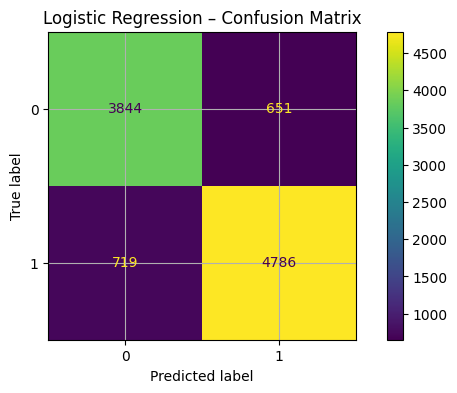

In [19]:
# ================================
# 3. LOGISTIC REGRESSION MODEL
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Build a full pipeline:
#   1. Preprocess data (scaling + one-hot encoding)
#   2. Fit logistic regression model
log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,       # allow more iterations to ensure convergence
        class_weight="balanced"  # helps if approvals/denials are imbalanced
    ))
])

# Fit the model on the training data
log_reg_clf.fit(X_train, y_train)

# Predict class labels (0/1) on the test data
y_pred_lr = log_reg_clf.predict(X_test)

# Predict probabilities of class 1 (approved) – for ROC-AUC and later analysis
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

# ===== EVALUATION METRICS =====
print("=== Logistic Regression Performance on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_lr))

# Confusion matrix: shows counts of TP, FP, TN, FN
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression – Confusion Matrix")
plt.show()


=== Random Forest Performance on Test Set ===
Accuracy: 0.9079
Precision: 0.9045181786092481
Recall: 0.9309718437783833
F1 Score: 0.9175543818816578
ROC-AUC: 0.9717697229437492

Detailed classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      4495
           1       0.90      0.93      0.92      5505

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



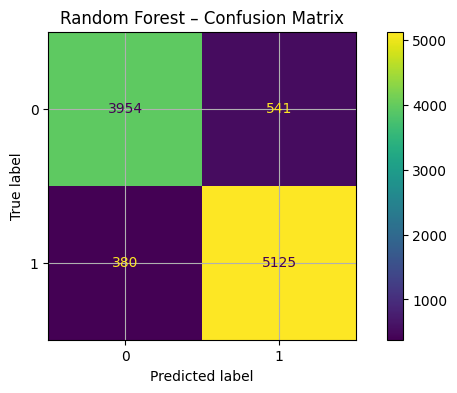

In [20]:
# ================================
# 4. RANDOM FOREST MODEL
# ================================

from sklearn.ensemble import RandomForestClassifier

# Build a pipeline:
#   1. Same preprocessing (scaling numerics, one-hot categoricals)
#   2. RandomForestClassifier
rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,     # number of trees
        max_depth=None,       # let trees grow fully (can tune later)
        n_jobs=-1,            # use all CPU cores
        random_state=42,
        class_weight="balanced"  # handle class imbalance
    ))
])

# Fit the RF model
rf_clf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest Performance on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest – Confusion Matrix")
plt.show()


In [21]:
# ================================
# 5. COMPARE LOGISTIC REGRESSION VS RANDOM FOREST
# ================================

results = []

results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
})

results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
})

results_df = pd.DataFrame(results)
display(results_df)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8630,0.880265,0.869391,0.874794,0.944518
1,Random Forest,0.9079,0.904518,0.930972,0.917554,0.971770


,feature,importance
3,credit_score,0.119704
12,debt_to_income_ratio,0.091845
11,interest_rate,0.069509
4,credit_history_years,0.049617
0,age,0.042985
8,delinquencies_last_2yrs,0.039503
6,current_debt,0.038702
1,years_employed,0.037435
14,payment_to_income_ratio,0.036122
13,loan_to_income_ratio,0.035628


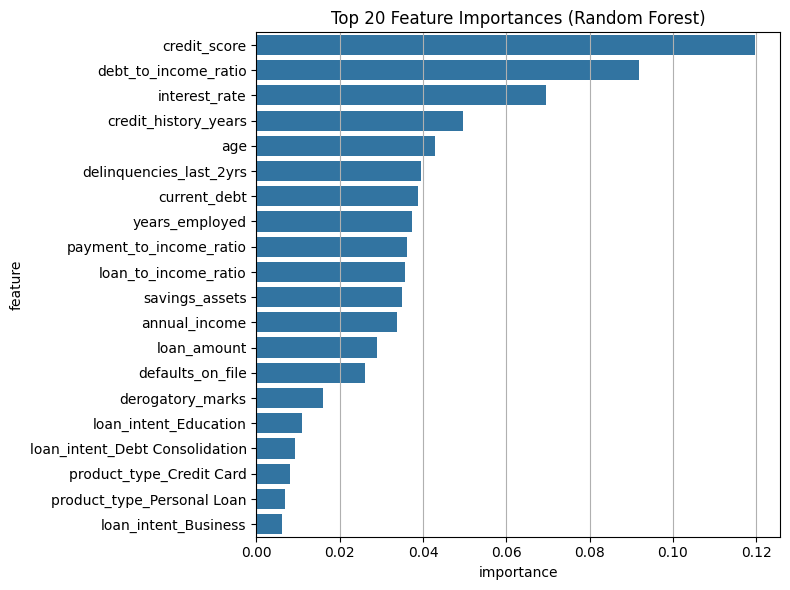

In [22]:
# ================================
# 6. FEATURE IMPORTANCE (RANDOM FOREST)
# ================================

# To get feature importances, we need:
#   1. The trained RandomForest model (inside the pipeline)
#   2. The full list of transformed feature names

# Step 1: grab the trained RF model
rf_model = rf_clf.named_steps["model"]

# Step 2: get the columns after preprocessing.
#   - numeric features stay the same
#   - categorical features are expanded into one column per category
ohe = rf_clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

# Combine numeric + expanded categorical names
all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

# Feature importances from the RF model (one value per feature)
importances = rf_model.feature_importances_

# Build a DataFrame for easier viewing/sorting
feat_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Show top 20 most important features
display(feat_imp_df.head(20))

# Plot them
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
